<a href="https://colab.research.google.com/github/ishikabeniwal/CSET343/blob/main/Assignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

In [2]:

cancer = load_breast_cancer()

# Create DataFrame
df = pd.DataFrame(
    cancer.data,
    columns=cancer.feature_names
)

# Add target column
df["Outcome"] = cancer.target

print("First 5 rows of dataset:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

First 5 rows of dataset:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  wor

In [3]:
print("\nMean of Features:")
print(df.mean(numeric_only=True))

print("\nMedian of Features:")
print(df.median(numeric_only=True))

print("\nStandard Deviation of Features:")
print(df.std(numeric_only=True))


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoo

In [4]:
print("\nMissing Values:")
print(df.isnull().sum())

print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())

# Remove duplicates if present
df = df.drop_duplicates()


Missing Values:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
Outcome                    0
dtype: int64

Number of Duplicate Rows:
0


In [5]:

# 6. Check Outliers using IQR


# Select only feature columns
X_features = df.drop("Outcome", axis=1)

Q1 = X_features.quantile(0.25)
Q3 = X_features.quantile(0.75)

IQR = Q3 - Q1

outliers = (
    (X_features < (Q1 - 1.5 * IQR)) |
    (X_features > (Q3 + 1.5 * IQR))
).sum()

print("\nOutliers in Each Feature:")
print(outliers)



Outliers in Each Feature:
mean radius                14
mean texture                7
mean perimeter             13
mean area                  25
mean smoothness             6
mean compactness           16
mean concavity             18
mean concave points        10
mean symmetry              15
mean fractal dimension     15
radius error               38
texture error              20
perimeter error            38
area error                 65
smoothness error           30
compactness error          28
concavity error            22
concave points error       19
symmetry error             27
fractal dimension error    28
worst radius               17
worst texture               5
worst perimeter            15
worst area                 35
worst smoothness            7
worst compactness          16
worst concavity            12
worst concave points        0
worst symmetry             23
worst fractal dimension    24
dtype: int64


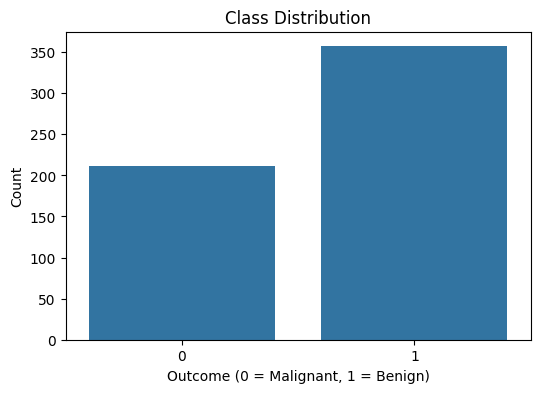


Class Distribution:
Outcome
1    357
0    212
Name: count, dtype: int64


In [6]:

# 7. Visualize Class Distribution

plt.figure(figsize=(6, 4))

sns.countplot(
    x="Outcome",
    data=df
)

plt.title("Class Distribution")
plt.xlabel("Outcome (0 = Malignant, 1 = Benign)")
plt.ylabel("Count")
plt.show()

print("\nClass Distribution:")
print(df["Outcome"].value_counts())


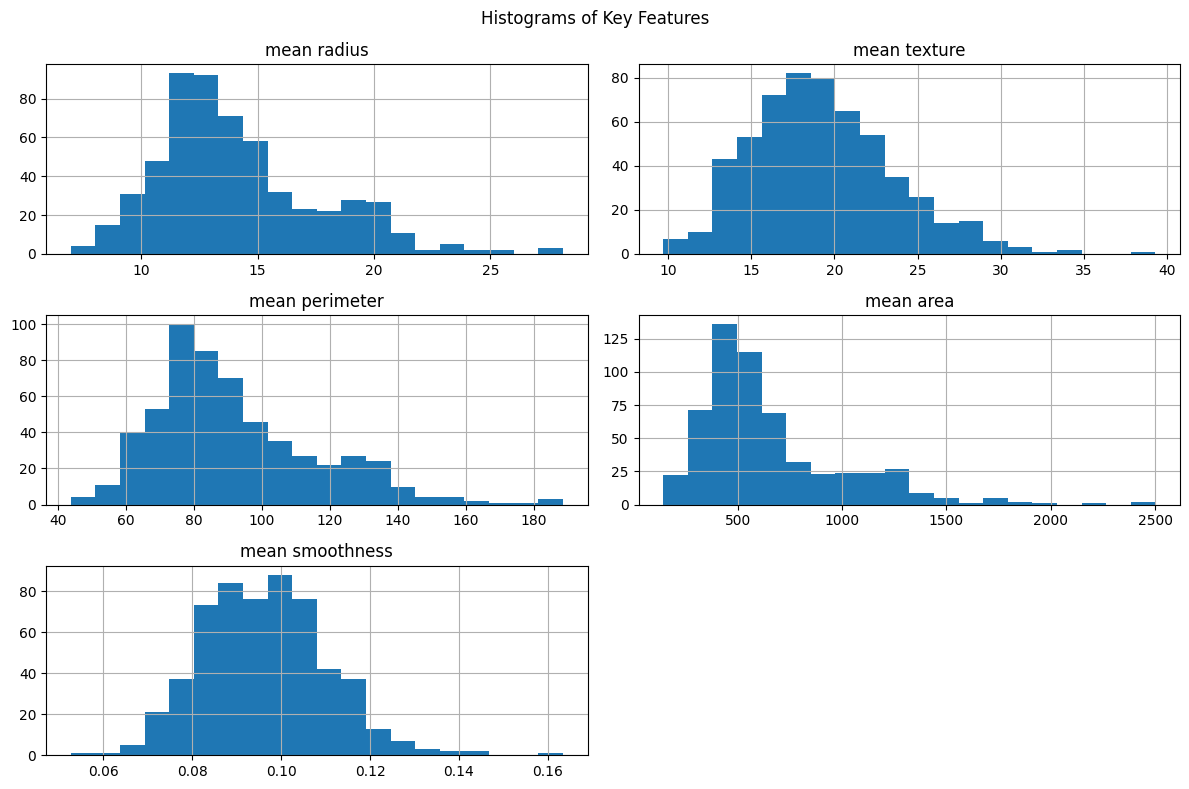

In [7]:

# 8. Histograms of Key Features

df[["mean radius", "mean texture", "mean perimeter",
    "mean area", "mean smoothness"]].hist(
    figsize=(12, 8),
    bins=20
)

plt.suptitle("Histograms of Key Features")
plt.tight_layout()
plt.show()

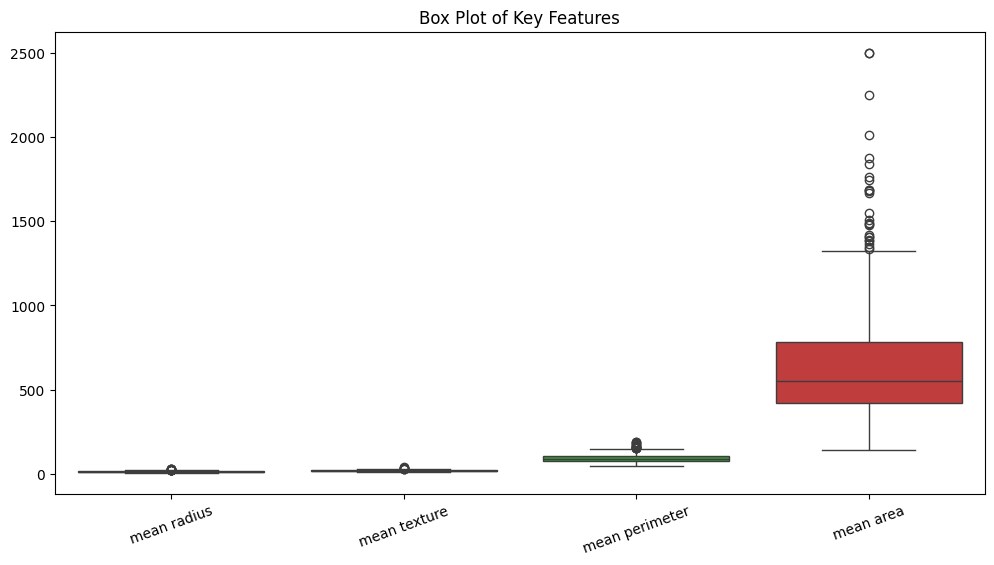

In [8]:
# 9. Box Plots for Key Features


plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df[["mean radius", "mean texture",
             "mean perimeter", "mean area"]]
)

plt.title("Box Plot of Key Features")
plt.xticks(rotation=20)
plt.show()

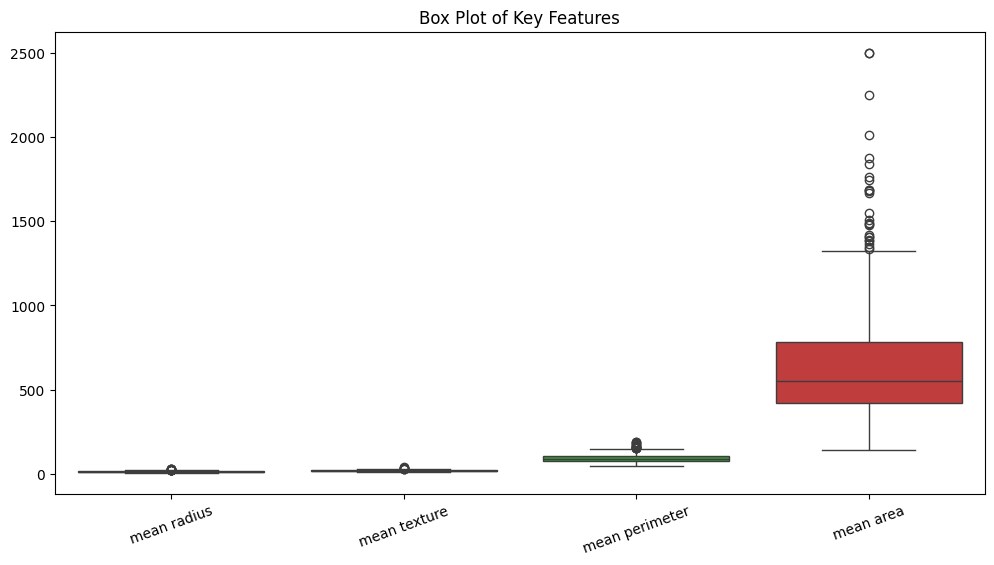

In [9]:
# 9. Box Plots for Key Features


plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df[["mean radius", "mean texture",
             "mean perimeter", "mean area"]]
)

plt.title("Box Plot of Key Features")
plt.xticks(rotation=20)
plt.show()

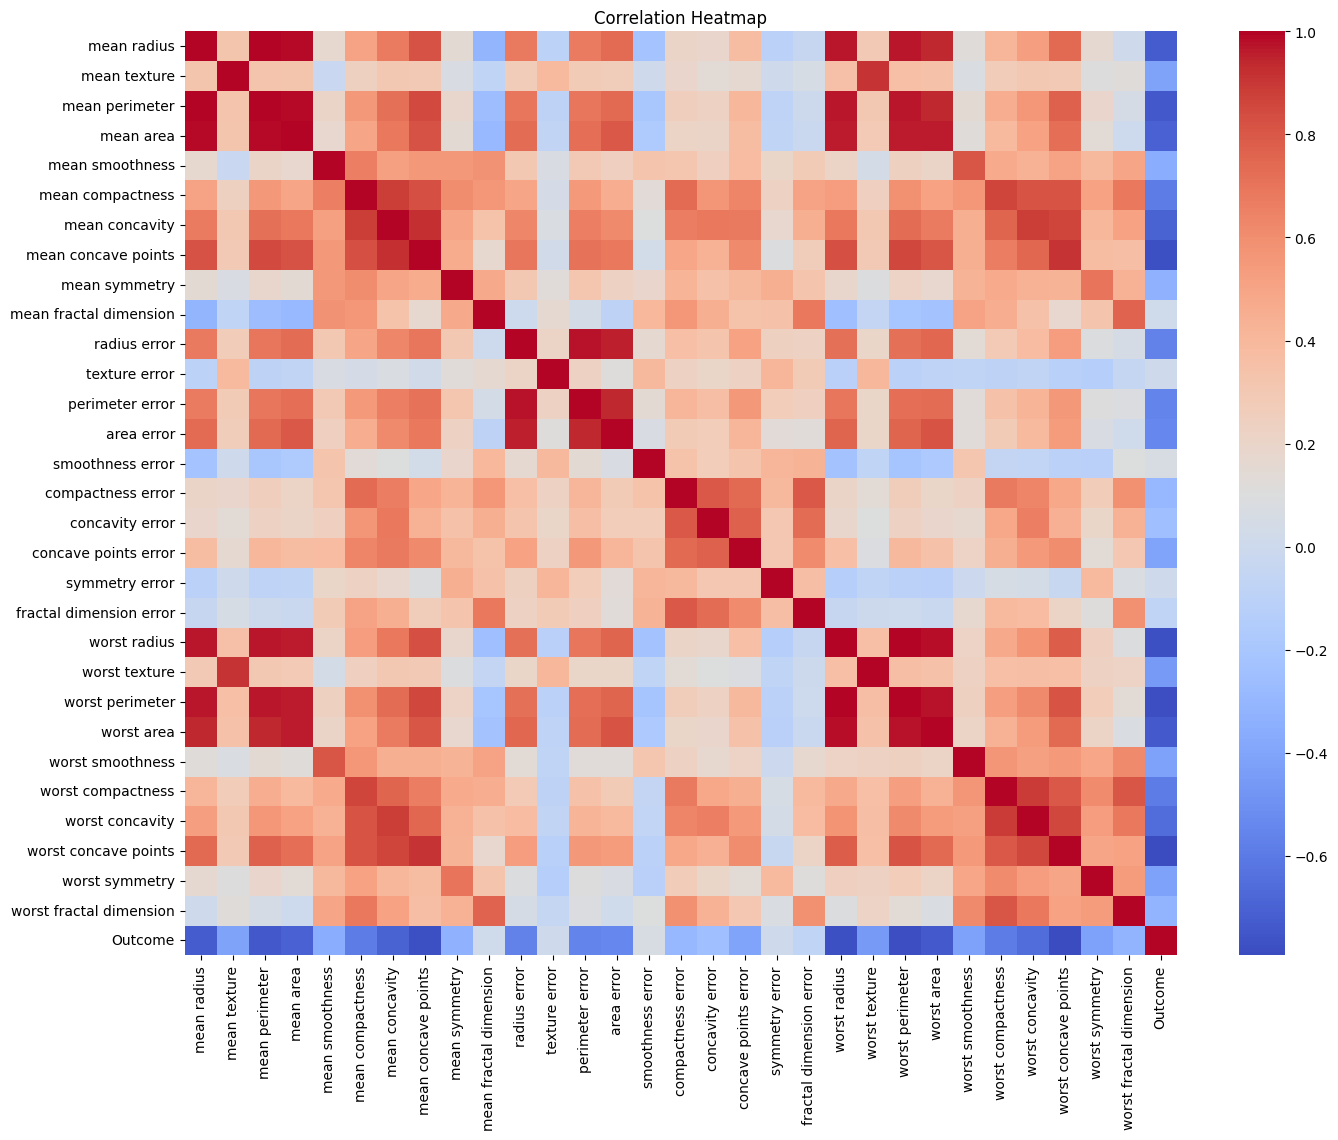

In [10]:
# 10. Correlation Heatmap

plt.figure(figsize=(16, 12))

correlation = df.corr()

sns.heatmap(
    correlation,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")
plt.show()

In [11]:
# 11. Prepare Features and Target


X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)


Feature Shape: (569, 30)
Target Shape: (569,)


In [12]:
# 12. Train-Test Split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)



Training Data Shape: (455, 30)
Testing Data Shape: (114, 30)


In [13]:
# 13. Feature Standardization


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# 14. Train Logistic Regression


model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("\nLogistic Regression Model Trained Successfully!")


Logistic Regression Model Trained Successfully!


In [14]:
# 15. Make Predictions


y_pred = model.predict(X_test_scaled)

# Probability of positive class
y_prob = model.predict_proba(X_test_scaled)[:, 1]


# 16. Accuracy


accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)



Accuracy: 0.9824561403508771


In [15]:
# 17. Precision, Recall, F1-Score


precision = precision_score(y_test, y_pred, average=None)
recall = recall_score(y_test, y_pred, average=None)
f1 = f1_score(y_test, y_pred, average=None)

print("\nPrecision for Class 0:", precision[0])
print("Precision for Class 1:", precision[1])

print("\nRecall for Class 0:", recall[0])
print("Recall for Class 1:", recall[1])

print("\nF1-Score for Class 0:", f1[0])
print("F1-Score for Class 1:", f1[1])


Precision for Class 0: 0.9761904761904762
Precision for Class 1: 0.9861111111111112

Recall for Class 0: 0.9761904761904762
Recall for Class 1: 0.9861111111111112

F1-Score for Class 0: 0.9761904761904762
F1-Score for Class 1: 0.9861111111111112



Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Confusion Matrix:
[[41  1]
 [ 1 71]]


<Figure size 600x500 with 0 Axes>

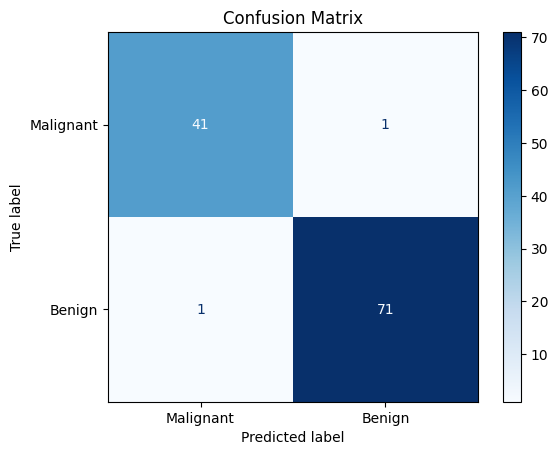

In [16]:
# 18. Classification Report


print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Malignant", "Benign"]
    )
)


# 19. Confusion Matrix


cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Malignant", "Benign"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()


AUC Score: 0.9953703703703703


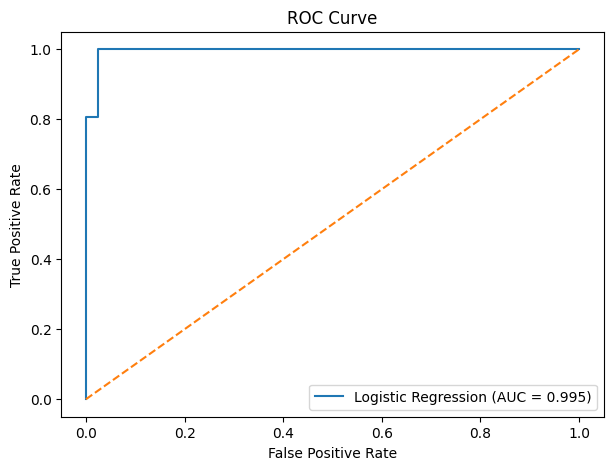

In [17]:
# 20. ROC Curve and AUC
# -----------------------------

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

print("\nAUC Score:", auc_score)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()